# Brasaland Sales Forecasting (Context-19)

Random Forest model predicting monthly **`revenue_usd`** with an honest **8-year train / 2-year holdout test** split.

## How to run (quick start)

1. **Kernel:** Select **Brasaland Forecasting (Python 3.12)** (top-right in Cursor, or Kernel menu in browser).
2. **Restart kernel** if a previous run failed with import errors (`Kernel → Restart`).
3. **Run cells top to bottom:** `Shift+Enter` on each cell, or **Run All**.
4. Cell 1 adds the repo to Python's path and clears a known `data/` name clash with `services/api/data/`.
5. Charts appear inline; PNGs save to `docs/forecasting/outputs/`.

**Where the code lives:** The notebook is the *report*. Real logic is in `data/forecasting/` (`load.py`, `train.py`, `visualize.py`, etc.).

In [3]:
import sys
from pathlib import Path

# Find repo root (folder containing data/forecasting/load.py)
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / "data" / "forecasting" / "load.py").is_file():
    _repo_root = _repo_root.parent
if not (_repo_root / "data" / "forecasting" / "load.py").is_file():
    raise RuntimeError(
        f"Cannot find Brasaland repo root from cwd={Path.cwd()}. "
        "Open this notebook from the project workspace."
    )

if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

# Kernel cwd is often services/api — its data/ folder shadows repo data/ and gets cached on failed import
for _name in list(sys.modules):
    if _name == "data" or _name.startswith("data."):
        del sys.modules[_name]

import matplotlib.pyplot as plt

from data.forecasting.load import load_sales
from data.forecasting.split import temporal_train_test_split
from data.forecasting.visualize import (
    CAPTIONS,
    DEFAULT_OUTPUT_DIR,
    build_visual_context,
    metrics_table_markdown,
    plot_v1_forecast_with_band,
    plot_v2_train_test_timeline,
    plot_v3_monthly_errors,
    plot_v5_binned_distribution,
    plot_v6_feature_importance,
    plot_v7_seasonality_by_month,
    plot_v8_residuals,
    write_metrics_summary,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = DEFAULT_OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {_repo_root}")
print(f"Outputs -> {OUTPUT_DIR}")

Repo root: /workspaces/shaunM12_Brasaland-Website
Outputs -> /workspaces/shaunM12_Brasaland-Website/docs/forecasting/outputs


In [4]:
raw = load_sales()
train_raw, test_raw = temporal_train_test_split(raw)
print(f"Raw rows: {len(raw)} | train: {len(train_raw)} | test: {len(test_raw)}")

ctx = build_visual_context(raw)
print("Holdout metrics:", ctx.metrics.as_dict())

Raw rows: 120 | train: 96 | test: 24
Holdout metrics: {'mse': 3386101902.594423, 'psi': 4.476669631739815, 'gini': 0.7413710451157502, 'k2': 15999999.657146862}


## V2 — Training vs holdout timeline

The model was fit only on the training period; holdout months were unseen during training.

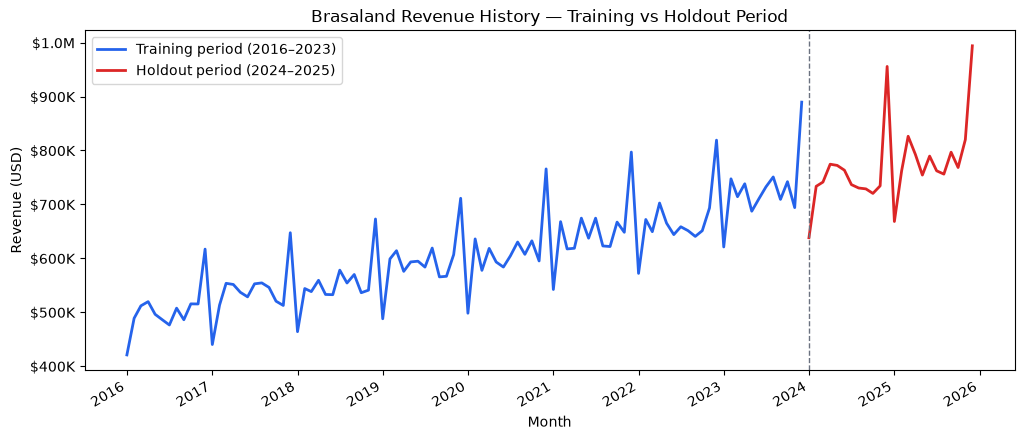

In [5]:
plot_v2_train_test_timeline(ctx.raw_frame, output_path=OUTPUT_DIR / "v2_train_test_timeline.png")
plt.show()

## V1 — Holdout forecast with uncertainty band

Shows whether monthly forecasts match actual sales and how wide the model's uncertainty is.

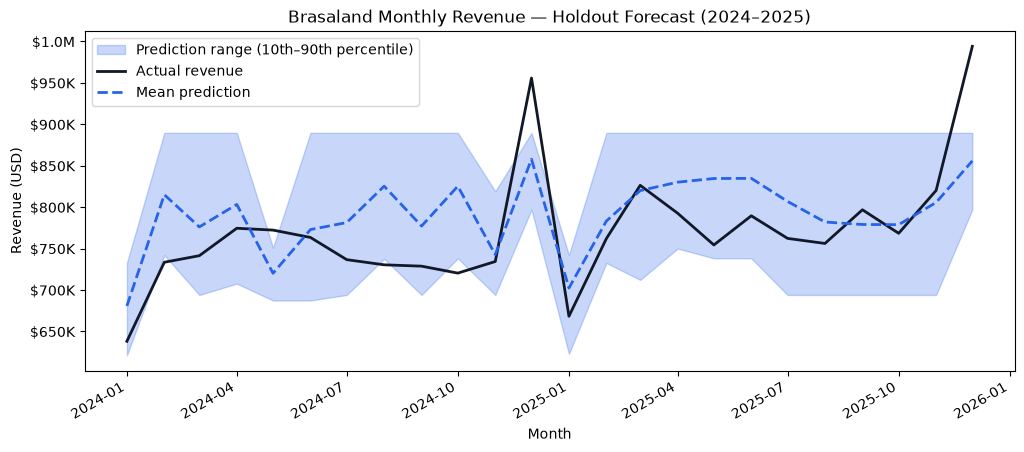

In [6]:
plot_v1_forecast_with_band(ctx, output_path=OUTPUT_DIR / "v1_forecast_with_band.png")
plt.show()

## V3 — Monthly forecast errors

Positive bars = underprediction; negative = overprediction.

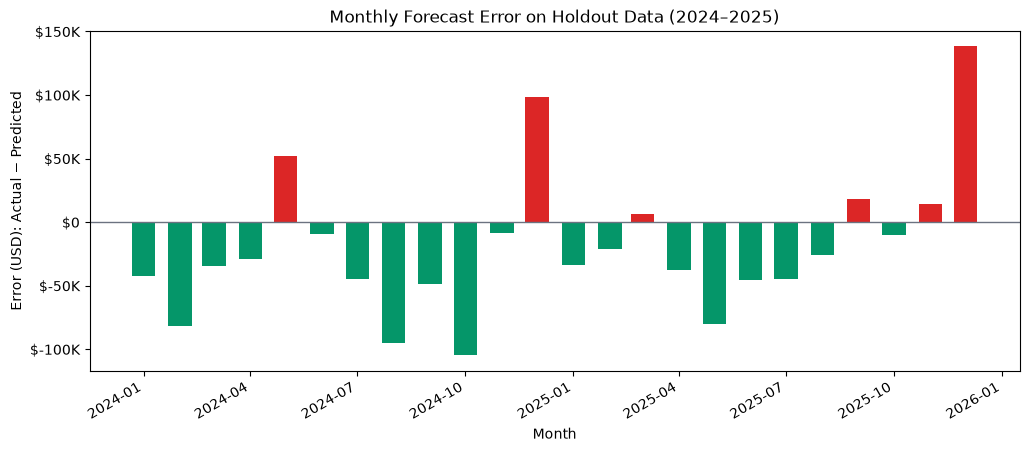

In [7]:
plot_v3_monthly_errors(ctx, output_path=OUTPUT_DIR / "v3_monthly_errors.png")
plt.show()

## V5 — Binned actual vs predicted distribution

Supports PSI and K2: mismatched bar heights indicate systematic bias in certain revenue ranges.

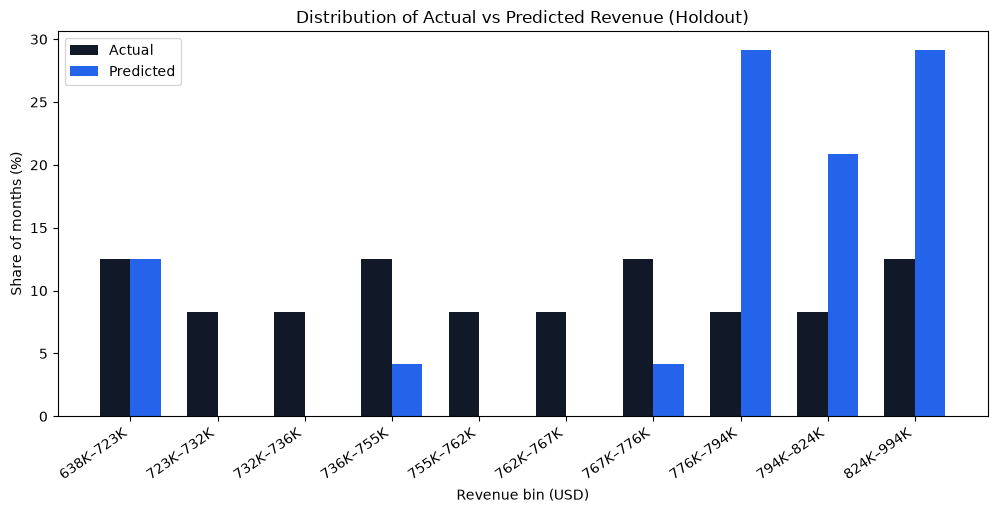

In [8]:
plot_v5_binned_distribution(ctx, output_path=OUTPUT_DIR / "v5_binned_distribution.png")
plt.show()

## V4 — Holdout metrics summary

Low MSE alone does not guarantee a good model; PSI, Gini, and K2 catch drift, ranking, and range-level bias.

Metrics are computed on the **2024–2025 holdout only** (never seen during training).

In [9]:
summary_md = metrics_table_markdown(ctx.metrics)
write_metrics_summary(ctx.metrics, OUTPUT_DIR / "v4_metrics_summary.md")
print(summary_md)

### Model Evaluation on Holdout Period (2024–2025)

| Metric | Value | What it means |
| ------ | ----- | ------------- |
| MSE | 3,386,101,902.59 | Average squared error in USD²; lower is better. |
| PSI | 4.4767 | Distribution drift between actual and predicted revenue. |
| Gini | 0.7414 | Ranking quality of predictions vs actuals (1.0 = perfect). |
| K2 | 15,999,999.66 | Chi-square on binned distributions; closer to 0 is better. |

Low MSE alone does not guarantee a good model; PSI, Gini, and K2 catch drift, ranking, and range-level bias.


## V6 — Feature importance

Shows which inputs (e.g. last month's revenue, seasonality) matter most.

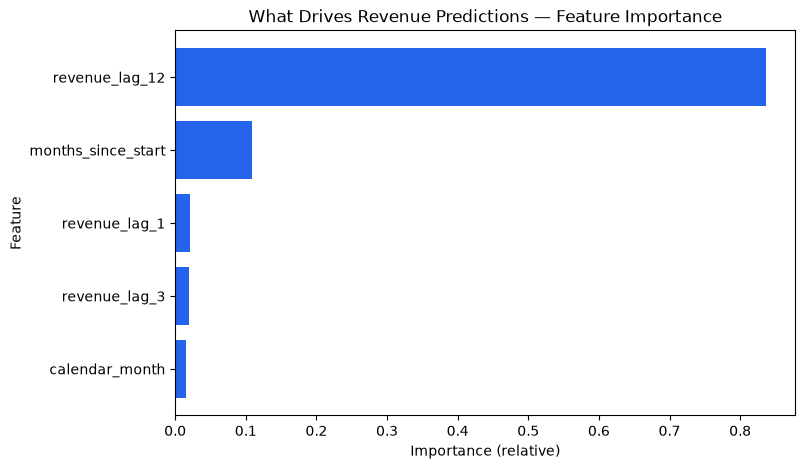

In [10]:
plot_v6_feature_importance(
    ctx.artifacts.model,
    ctx.artifacts.feature_names,
    output_path=OUTPUT_DIR / "v6_feature_importance.png",
)
plt.show()

## V7 — Seasonality by calendar month (holdout)

Validates whether the model captures recurring monthly effects (e.g. year-end peaks).

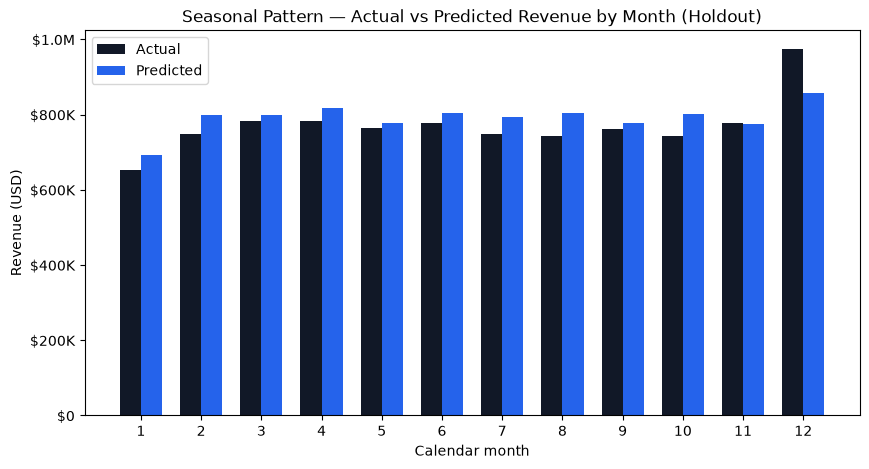

In [11]:
plot_v7_seasonality_by_month(ctx, output_path=OUTPUT_DIR / "v7_seasonality_by_month.png")
plt.show()

## V8 — Residual analysis

A clear trend in residuals suggests the model under- or over-predicts at certain revenue levels.

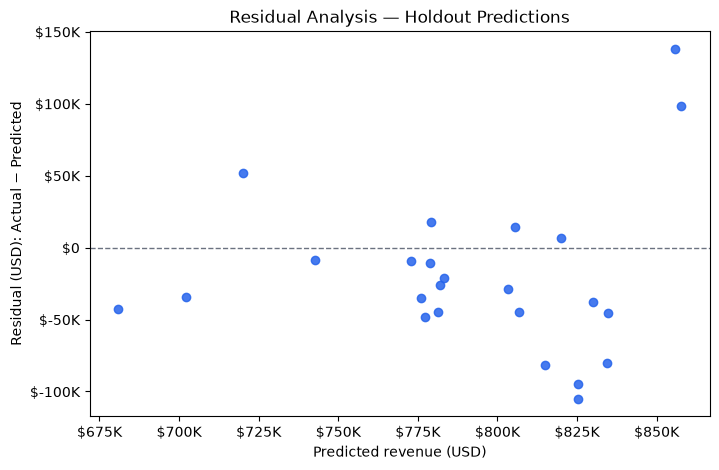

In [12]:
plot_v8_residuals(ctx, output_path=OUTPUT_DIR / "v8_residuals.png")
plt.show()

## Finance summary

This notebook trains a **Random Forest** on 2016–2023 revenue history (with lag features) and evaluates on **2024–2025** only. Predictions include a **10th–90th percentile** band across trees so Finance sees a range, not a single optimistic point.